# Maximizing Revenue for Drivers Through Payment Type Analysis

## Objective
- To evaluate whether payment method (Credit vs Cash) is associated with differences in total trip revenue using NYC TLC 2025 Yellow Taxi data.

- This project applies statistical analysis, non-parametric hypothesis testing, and economic interpretation.

## Data Source

Data obtained from the official NYC Taxi & Limousine Commission (TLC):

https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

Dataset:
- Yellow Taxi Trip Records (2025)
- Monthly parquet files
- Trip-level transactional data

The dataset contains anonymized trip information including timestamps, distance, payment type, fare, tip, and total amount.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set(style="whitegrid")

## Data Loading
Selected three representative months (Jan, Jun, Oct) to balance seasonality and computational feasibility.

In [5]:
columns_needed = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "passenger_count",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount"
]

In [6]:
files = [
    "data/yellow_tripdata_2025-01.parquet",
    "data/yellow_tripdata_2025-06.parquet",
    "data/yellow_tripdata_2025-10.parquet"
]

df_list = []

for file in files:
    print(f"Loading {file}...")
    temp_df = pd.read_parquet(file, columns=columns_needed)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

df.shape

Loading data/yellow_tripdata_2025-01.parquet...
Loading data/yellow_tripdata_2025-06.parquet...
Loading data/yellow_tripdata_2025-10.parquet...


(12226885, 8)

In [7]:
df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,passenger_count,payment_type,fare_amount,tip_amount,total_amount
0,2025-01-01 00:18:38,2025-01-01 00:26:59,1.60,1.0,1,10.0,3.00,18.00
1,2025-01-01 00:32:40,2025-01-01 00:35:13,0.50,1.0,1,5.1,2.02,12.12
2,2025-01-01 00:44:04,2025-01-01 00:46:01,0.60,1.0,1,5.1,2.00,12.10
3,2025-01-01 00:14:27,2025-01-01 00:20:01,0.52,3.0,2,7.2,0.00,9.70
4,2025-01-01 00:21:34,2025-01-01 00:25:06,0.66,3.0,2,5.8,0.00,8.30


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12226885 entries, 0 to 12226884
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   trip_distance          float64       
 3   passenger_count        float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 746.3 MB


## Data Cleaning

To ensure valid statistical inference, the following filters were applied:

- Removed trips with non-positive fare or total amount.
- Removed trips with unrealistic distance (>100 miles).
- Removed trips with unrealistic total_amount (>500 USD).
- Removed trips shorter than 1 minute or longer than 3 hours.
- Restricted analysis to voluntary payment types:
    1 = Credit Card
    2 = Cash
- Derived trip duration from timestamps.
- Created revenue_per_mile and tip_percentage metrics.
- Trimmed extreme ratio outliers caused by small denominators.

In [9]:
df.shape

(12226885, 8)

In [10]:
df.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,passenger_count,payment_type,fare_amount,tip_amount,total_amount
count,12226885,12226885,1.222688e+07,9.482903e+06,1.222688e+07,1.222688e+07,1.222688e+07,1.222688e+07
mean,2025-06-17 23:28:08.897826,2025-06-17 23:45:20.023649,6.733883e+00,1.289639e+00,9.508702e-01,1.817737e+01,2.897861e+00,2.673263e+01
min,2024-12-31 20:47:55,2024-12-18 07:52:40,0.000000e+00,0.000000e+00,0.000000e+00,-9.900000e+02,-9.000000e+01,-9.942500e+02
25%,2025-01-28 19:19:31,2025-01-28 19:33:01,1.030000e+00,1.000000e+00,1.000000e+00,8.600000e+00,0.000000e+00,1.556000e+01
50%,2025-06-19 09:27:02,2025-06-19 09:42:44,1.820000e+00,1.000000e+00,1.000000e+00,1.350000e+01,2.150000e+00,2.106000e+01
75%,2025-10-10 19:58:41,2025-10-10 20:17:06,3.630000e+00,1.000000e+00,1.000000e+00,2.222000e+01,4.000000e+00,3.030000e+01
max,2025-11-01 00:32:12,2025-11-03 09:38:20,2.764236e+05,9.000000e+00,5.000000e+00,8.633721e+05,9.609400e+02,8.633804e+05
std,NaN,NaN,6.460160e+02,7.239410e-01,7.367408e-01,2.645700e+02,3.978232e+00,2.649183e+02


In [11]:
df["trip_duration_min"] = (
    (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
    .dt.total_seconds() / 60
)

## Feature Engineering

Trip duration was derived from pickup and dropoff timestamps to enable filtering and rate-based analysis.

In [12]:
df["trip_duration_min"].describe()

count    1.222688e+07
mean     1.718543e+01
std      3.069961e+01
min     -5.147232e+04
25%      8.016667e+00
50%      1.331667e+01
75%      2.128333e+01
max      8.596100e+03
Name: trip_duration_min, dtype: float64

## Data Cleaning

To ensure valid statistical inference, the following filters were applied:

- Removed non-positive fares and total amounts.
- Removed unrealistic trip distances (>100 miles).
- Removed unrealistic total amounts (>500 USD).
- Removed trips shorter than 1 minute or longer than 3 hours.
- Excluded administrative payment types (0, 3, 4, 5).
- Restricted analysis to voluntary payment types:
    1 = Credit Card
    2 = Cash

These steps prevent distorted inference due to data-entry errors and extreme outliers.

In [13]:
df = df[
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0) &
    (df["total_amount"] > 0) &
    (df["trip_duration_min"] > 1) &
    (df["trip_distance"] < 100) &
    (df["total_amount"] < 500) &
    (df["trip_duration_min"] < 180)
]

In [14]:
df.shape

(11025668, 9)

In [15]:
df.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,passenger_count,payment_type,fare_amount,tip_amount,total_amount,trip_duration_min
count,11025668,11025668,1.102567e+07,8.996047e+06,1.102567e+07,1.102567e+07,1.102567e+07,1.102567e+07,1.102567e+07
mean,2025-06-15 16:58:43.964239,2025-06-15 17:15:49.324159,3.475497e+00,1.286312e+00,9.543122e-01,1.970636e+01,3.106561e+00,2.859528e+01,1.708933e+01
min,2024-12-31 20:47:55,2024-12-31 20:54:00,1.000000e-02,0.000000e+00,0.000000e+00,1.000000e-02,0.000000e+00,1.010000e+00,1.016667e+00
25%,2025-01-27 18:49:44.750000,2025-01-27 19:02:49.750000,1.100000e+00,1.000000e+00,1.000000e+00,9.300000e+00,0.000000e+00,1.662000e+01,8.216667e+00
50%,2025-06-18 17:02:31,2025-06-18 17:23:13,1.870000e+00,1.000000e+00,1.000000e+00,1.420000e+01,2.500000e+00,2.190000e+01,1.336667e+01
75%,2025-10-10 11:54:24,2025-10-10 12:15:04,3.680000e+00,1.000000e+00,1.000000e+00,2.309000e+01,4.130000e+00,3.114000e+01,2.131667e+01
max,2025-11-01 00:32:12,2025-11-01 01:35:27,9.906000e+01,9.000000e+00,5.000000e+00,4.950000e+02,4.466700e+02,4.997500e+02,1.799667e+02
std,NaN,NaN,4.322137e+00,7.208441e-01,6.286887e-01,1.709222e+01,3.949135e+00,2.134946e+01,1.368233e+01


In [16]:
df = df[
    (df["trip_distance"] < 100) &
    (df["total_amount"] < 500) &
    (df["trip_duration_min"] < 180)
]

In [17]:
df.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,passenger_count,payment_type,fare_amount,tip_amount,total_amount,trip_duration_min
count,11025668,11025668,1.102567e+07,8.996047e+06,1.102567e+07,1.102567e+07,1.102567e+07,1.102567e+07,1.102567e+07
mean,2025-06-15 16:58:43.964239,2025-06-15 17:15:49.324159,3.475497e+00,1.286312e+00,9.543122e-01,1.970636e+01,3.106561e+00,2.859528e+01,1.708933e+01
min,2024-12-31 20:47:55,2024-12-31 20:54:00,1.000000e-02,0.000000e+00,0.000000e+00,1.000000e-02,0.000000e+00,1.010000e+00,1.016667e+00
25%,2025-01-27 18:49:44.750000,2025-01-27 19:02:49.750000,1.100000e+00,1.000000e+00,1.000000e+00,9.300000e+00,0.000000e+00,1.662000e+01,8.216667e+00
50%,2025-06-18 17:02:31,2025-06-18 17:23:13,1.870000e+00,1.000000e+00,1.000000e+00,1.420000e+01,2.500000e+00,2.190000e+01,1.336667e+01
75%,2025-10-10 11:54:24,2025-10-10 12:15:04,3.680000e+00,1.000000e+00,1.000000e+00,2.309000e+01,4.130000e+00,3.114000e+01,2.131667e+01
max,2025-11-01 00:32:12,2025-11-01 01:35:27,9.906000e+01,9.000000e+00,5.000000e+00,4.950000e+02,4.466700e+02,4.997500e+02,1.799667e+02
std,NaN,NaN,4.322137e+00,7.208441e-01,6.286887e-01,1.709222e+01,3.949135e+00,2.134946e+01,1.368233e+01


payment type distribution

In [18]:
df["payment_type"].value_counts(normalize=True)

payment_type
1    7.036084e-01
0    1.840815e-01
2    9.757368e-02
4    1.134698e-02
3    3.389364e-03
5    9.069745e-08
Name: proportion, dtype: float64

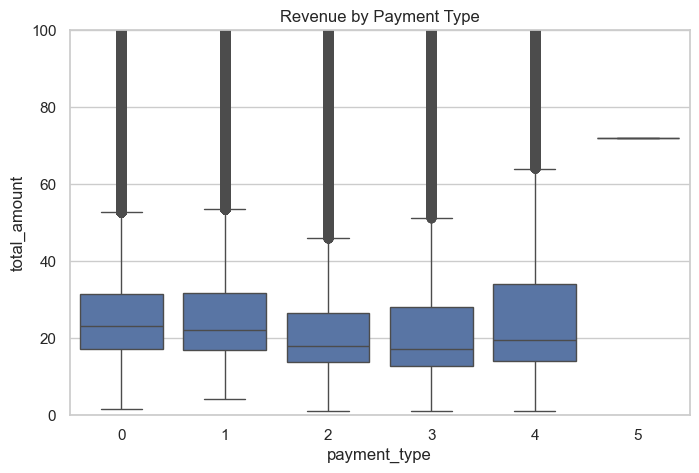

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="payment_type", y="total_amount", data=df)
plt.ylim(0, 100)
plt.title("Revenue by Payment Type")
plt.show()

In [20]:
df["payment_type"].value_counts()

payment_type
1    7757753
0    2029621
2    1075815
4     125108
3      37370
5          1
Name: count, dtype: int64

In [21]:
df[df["payment_type"] == 0].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,passenger_count,payment_type,fare_amount,tip_amount,total_amount,trip_duration_min
2935077,2025-01-01 00:39:17,2025-01-01 01:10:42,6.75,NaN,0,2.32,0.0,14.90,31.416667
2935078,2025-01-01 00:33:40,2025-01-01 01:10:34,3.88,NaN,0,6.02,0.0,10.02,36.900000
2935081,2025-01-01 00:56:04,2025-01-01 01:06:11,1.55,NaN,0,5.06,0.0,9.06,10.116667
2935082,2025-01-01 00:33:36,2025-01-01 00:54:48,2.60,NaN,0,18.42,0.0,22.42,21.200000
2935083,2025-01-01 00:50:25,2025-01-01 00:57:34,1.04,NaN,0,14.16,2.0,20.16,7.150000


In [22]:
df.groupby("payment_type")[["fare_amount", "tip_amount", "total_amount"]].mean()

,fare_amount,tip_amount,total_amount
payment_type,,,
0,20.639296,0.403389,25.613487
1,19.462370,4.309451,29.868367
2,19.230556,0.000326,24.966200
3,20.459215,0.010879,26.433841
4,23.567564,0.006162,29.878558
5,51.800000,0.000000,71.990000


In [23]:
df.groupby("payment_type")[["fare_amount", "tip_amount", "total_amount"]].median()

,fare_amount,tip_amount,total_amount
payment_type,,,
0,18.43,0.0,23.06
1,13.50,3.3,22.05
2,12.80,0.0,17.90
3,12.10,0.0,17.25
4,14.20,0.0,19.35
5,51.80,0.0,71.99


In [24]:
df.groupby("payment_type")["tip_amount"].mean()

payment_type
0    0.403389
1    4.309451
2    0.000326
3    0.010879
4    0.006162
5    0.000000
Name: tip_amount, dtype: float64

In [25]:
df.groupby("payment_type")["tip_amount"].apply(lambda x: (x == 0).mean())

payment_type
0    0.912451
1    0.068613
2    0.999937
3    0.998582
4    0.999217
5    1.000000
Name: tip_amount, dtype: float64

In [26]:
df.groupby("payment_type")[["trip_distance", "trip_duration_min"]].median()

,trip_distance,trip_duration_min
payment_type,,
0,2.74,16.300000
1,1.72,12.700000
2,1.58,11.983333
3,1.40,11.066667
4,1.74,12.733333
5,10.00,61.700000


In [27]:
df_pay = df[df["payment_type"].isin([1, 2])].copy()

df_pay["payment_label"] = df_pay["payment_type"].map({
    1: "Credit",
    2: "Cash"
})

df_pay["payment_label"].value_counts()

payment_label
Credit    7757753
Cash      1075815
Name: count, dtype: int64

In [28]:
#Revenue Summary by Payment Type
df_pay.groupby("payment_label")["total_amount"].describe()

,count,mean,std,min,25%,50%,75%,max
payment_label,,,,,,,,
Cash,1075815.0,24.966200,20.634642,1.01,13.7,17.90,26.60,499.75
Credit,7757753.0,29.868367,22.870121,4.24,17.0,22.05,31.56,499.68


In [29]:
#Structural Differences
df_pay.groupby("payment_label")[["trip_distance", "trip_duration_min"]].median()

,trip_distance,trip_duration_min
payment_label,,
Cash,1.58,11.983333
Credit,1.72,12.700000


In [30]:
df_pay.groupby("payment_label")["tip_amount"].median()

payment_label
Cash      0.0
Credit    3.3
Name: tip_amount, dtype: float64

## Derived Metrics

Two analytical metrics were constructed:

- Revenue per Mile = total_amount / trip_distance  
- Tip Percentage = tip_amount / fare_amount  

These allow fairer comparison by adjusting for trip length and fare structure.

In [31]:
df_pay["revenue_per_mile"] = df_pay["total_amount"] / df_pay["trip_distance"]

df_pay["tip_percentage"] = np.where(
    df_pay["fare_amount"] > 0,
    df_pay["tip_amount"] / df_pay["fare_amount"],
    0
)

In [32]:
df_pay[["revenue_per_mile", "tip_percentage"]].describe()

,revenue_per_mile,tip_percentage
count,8.833568e+06,8.833568e+06
mean,1.432765e+01,2.229443e-01
std,3.479667e+01,2.369084e+00
min,2.645371e-02,0.000000e+00
25%,8.771186e+00,1.250000e-01
50%,1.229927e+01,2.531646e-01
75%,1.687500e+01,3.074766e-01
max,1.796900e+04,7.000000e+03


In [33]:
#Compare Medians

In [34]:
#Total Revenue
df_pay.groupby("payment_label")["total_amount"].median()

payment_label
Cash      17.90
Credit    22.05
Name: total_amount, dtype: float64

In [35]:
#Revenue Per Mile
df_pay.groupby("payment_label")["revenue_per_mile"].median()

payment_label
Cash      11.035714
Credit    12.466667
Name: revenue_per_mile, dtype: float64

In [36]:
#Tip Percentage
df_pay.groupby("payment_label")["tip_percentage"].median()

payment_label
Cash      0.000000
Credit    0.264972
Name: tip_percentage, dtype: float64

## Statistical Hypothesis Testing

Because revenue distributions are non-normal and skewed, the Mann–Whitney U test was used to compare distributions between payment types.

Null Hypothesis (H₀):
The distribution of revenue is identical for credit and cash trips.

Alternative Hypothesis (H₁):
The distribution of revenue differs between payment types.

In [37]:
#Total Revenue Test
credit_rev = df_pay[df_pay["payment_label"] == "Credit"]["total_amount"]
cash_rev = df_pay[df_pay["payment_label"] == "Cash"]["total_amount"]

u_stat, p_value = mannwhitneyu(credit_rev, cash_rev, alternative="two-sided")

print("U statistic:", u_stat)
print("p-value:", p_value)

U statistic: 5203121381143.0
p-value: 0.0


In [38]:
#Revenue Per Mile Test
credit_rpm = df_pay[df_pay["payment_label"] == "Credit"]["revenue_per_mile"]
cash_rpm = df_pay[df_pay["payment_label"] == "Cash"]["revenue_per_mile"]

u_stat_rpm, p_value_rpm = mannwhitneyu(credit_rpm, cash_rpm, alternative="two-sided")

print("U statistic (RPM):", u_stat_rpm)
print("p-value (RPM):", p_value_rpm)

U statistic (RPM): 4741807051233.0
p-value (RPM): 0.0


In [39]:
#Tip Percentage Test
credit_tip = df_pay[df_pay["payment_label"] == "Credit"]["tip_percentage"]
cash_tip = df_pay[df_pay["payment_label"] == "Cash"]["tip_percentage"]

u_stat_tip, p_value_tip = mannwhitneyu(credit_tip, cash_tip, alternative="two-sided")

print("U statistic (Tip %):", u_stat_tip)
print("p-value (Tip %):", p_value_tip)

U statistic (Tip %): 8059306700141.0
p-value (Tip %): 0.0


In [40]:
df_pay = df_pay[
    (df_pay["revenue_per_mile"] < 200) &
    (df_pay["tip_percentage"] < 2)
]

In [41]:
#Effect Size Calculation
df_pay.groupby("payment_label")["total_amount"].median()

payment_label
Cash      17.95
Credit    22.05
Name: total_amount, dtype: float64

In [42]:
credit_median = df_pay[df_pay["payment_label"]=="Credit"]["total_amount"].median()
cash_median = df_pay[df_pay["payment_label"]=="Cash"]["total_amount"].median()

percentage_diff = (credit_median - cash_median) / cash_median * 100
percentage_diff

np.float64(22.841225626740954)

The p-value is effectively zero, indicating strong evidence against the null hypothesis.

Given the large sample size, effect size (median difference) is more meaningful than p-value alone.

## Exploratory Data Analysis

Distributional behavior was examined prior to hypothesis testing.

Revenue distributions were assessed visually to determine appropriate statistical methodology.

## Visualization

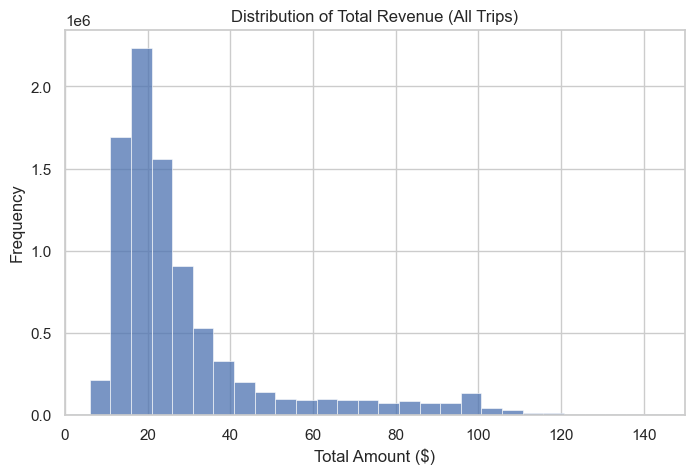

In [43]:
#Revenue Distribution

plt.figure(figsize=(8,5))
sns.histplot(df_pay["total_amount"], bins=100)
plt.xlim(0, 150)
plt.title("Distribution of Total Revenue (All Trips)")
plt.xlabel("Total Amount ($)")
plt.ylabel("Frequency")
plt.show()

### Distribution of Total Revenue

The distribution of total trip revenue exhibits strong right skewness, with the majority of trips concentrated between approximately \$10 and \$30.

A long right tail is observed, extending beyond \$100, indicating the presence of higher-value trips (e.g., airport rides or longer journeys). This skewed structure implies that the mean is influenced by extreme values.

Given this non-normal distribution, median-based comparisons and non-parametric statistical tests are more appropriate for inference.

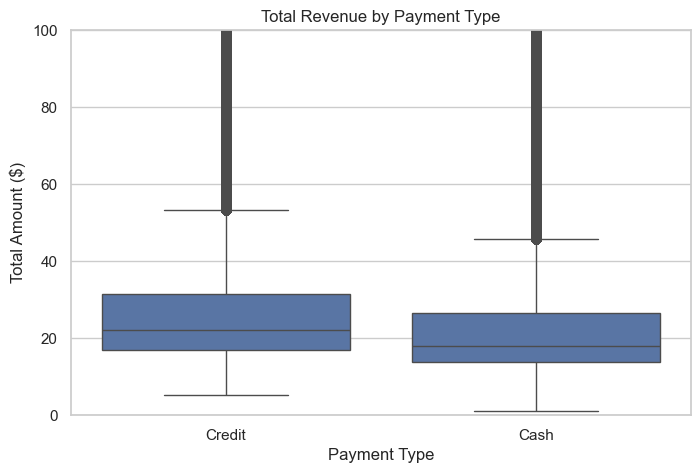

In [44]:
#Revenue by Payment Type

plt.figure(figsize=(8,5))
sns.boxplot(x="payment_label", y="total_amount", data=df_pay)
plt.ylim(0, 100)
plt.title("Total Revenue by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Total Amount ($)")
plt.show()

### Total Revenue by Payment Type

The boxplot comparison reveals that credit card trips have a visibly higher median total revenue compared to cash trips.

While both distributions are right-skewed, the interquartile range for credit payments is slightly higher, and the upper distribution extends further upward.

The median difference of approximately \$4 per trip is visually apparent, suggesting a meaningful revenue gap between payment types. This motivates formal hypothesis testing to assess statistical significance.

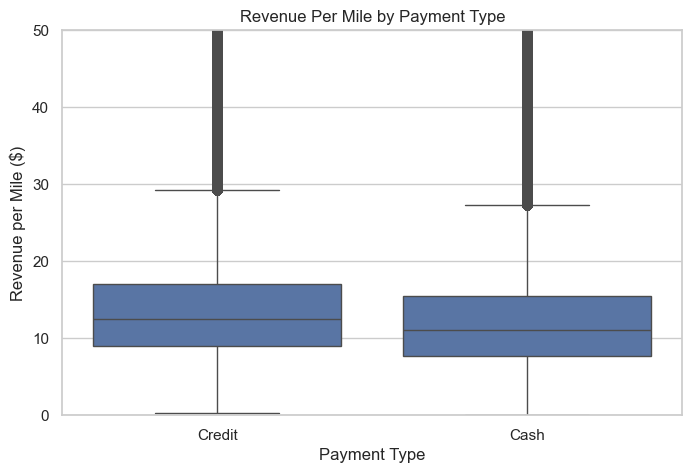

In [45]:
#Revenue Per Mile Comparison

plt.figure(figsize=(8,5))
sns.boxplot(x="payment_label", y="revenue_per_mile", data=df_pay)
plt.ylim(0, 50)
plt.title("Revenue Per Mile by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Revenue per Mile ($)")
plt.show()

### Revenue Per Mile by Payment Type

To control for differences in trip distance, revenue per mile was computed and compared across payment types.

The boxplot indicates that credit trips maintain a higher median revenue per mile than cash trips. Although the gap is smaller than in total revenue, the difference persists after adjusting for trip length.

This suggests that the revenue advantage associated with credit payments is not solely attributable to longer trips, reinforcing the need for statistical evaluation.

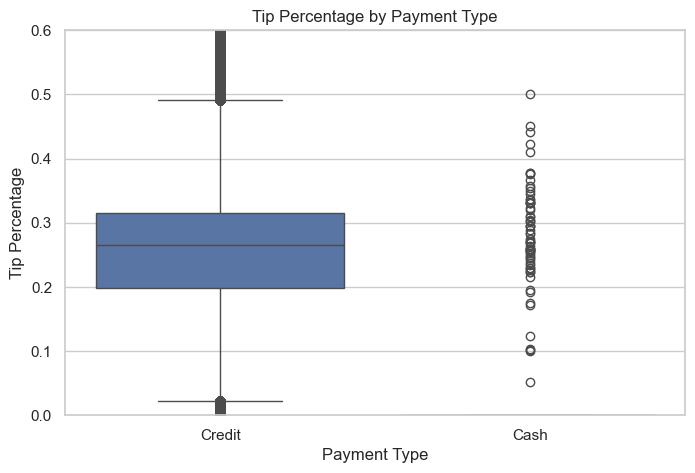

In [46]:
#Tip Percentage Distribution

plt.figure(figsize=(8,5))
sns.boxplot(x="payment_label", y="tip_percentage", data=df_pay)
plt.ylim(0, 0.6)
plt.title("Tip Percentage by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Tip Percentage")
plt.show()

### Tip Percentage by Payment Type

Tip percentage differs substantially between payment types.

Cash trips exhibit a median tip percentage of 0%, while credit trips show a median tip rate of approximately 25–27%.

The distribution of credit tipping is tightly concentrated within a typical tipping range (20–30%), whereas cash trips display minimal digitally recorded tipping.

This strong divergence indicates that tipping behavior is the primary mechanism driving the observed revenue differences.

In [47]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 6.1 MB/s  0:00:01 6.5 MB/s eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]


In [48]:
import statsmodels.api as sm

In [49]:
df_reg = df_pay.copy()

# Binary variable: Credit = 1, Cash = 0
df_reg["is_credit"] = np.where(df_reg["payment_label"] == "Credit", 1, 0)

In [50]:
X = df_reg[["is_credit", "trip_distance", "trip_duration_min"]]
y = df_reg["total_amount"]

# Add intercept
X = sm.add_constant(X)

In [51]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           total_amount   R-squared:                       0.877
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                 2.093e+07
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:40:27   Log-Likelihood:            -3.0820e+07
No. Observations:             8826751   AIC:                         6.164e+07
Df Residuals:                 8826747   BIC:                         6.164e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 7.6780      0.00

## Multivariate Regression Analysis

An OLS regression was performed to evaluate whether payment type remains associated with revenue after controlling for trip distance and duration.

The coefficient for `is_credit` was 4.46 (p < 0.001), indicating that credit card trips generate, on average, approximately $4.46 more revenue than cash trips, holding trip characteristics constant.

This result closely aligns with the median-based comparison (~$4 difference), reinforcing the robustness of the finding.

Trip distance and duration coefficients were positive and economically reasonable, suggesting the model captures fundamental fare structure.

While residuals exhibit non-normality due to skewed revenue distribution, the large sample size ensures stable coefficient estimation.

These results strengthen the conclusion that payment type is systematically associated with higher driver revenue.

## Discussion

Credit trips generate approximately 23% higher median revenue than cash trips.

The difference persists after adjusting for trip distance and is primarily driven by tipping behavior.

## Limitations

- Observational dataset (no causal inference)
- Geographic and temporal confounders not controlled
- Possible rider demographic effects
- Large sample size inflates statistical significance

## Conclusion

Digital payment methods are strongly associated with higher effective driver revenue.

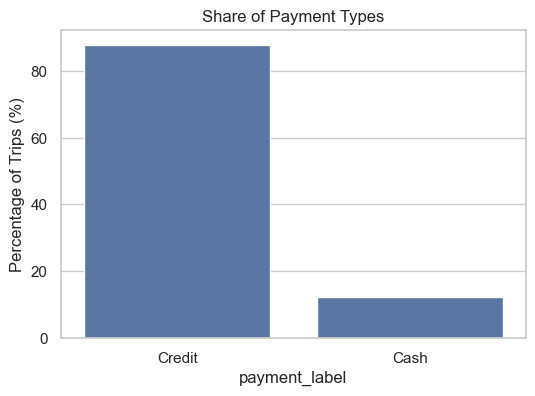

In [54]:
payment_counts = df_pay["payment_label"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
sns.barplot(x=payment_counts.index, y=payment_counts.values)
plt.ylabel("Percentage of Trips (%)")
plt.title("Share of Payment Types")
plt.show()

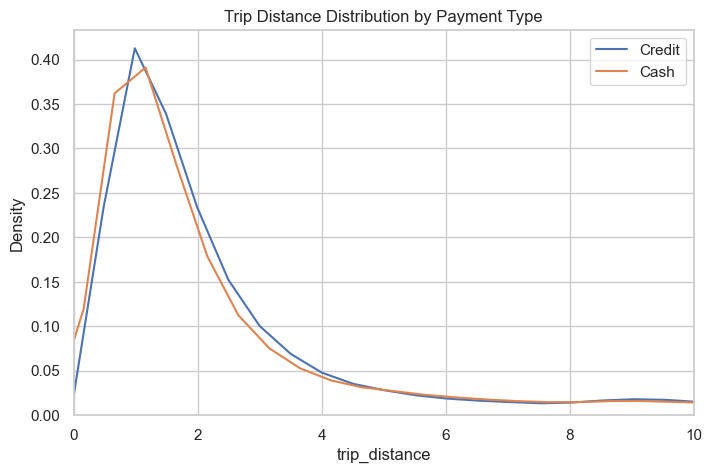

In [52]:
plt.figure(figsize=(8,5))
sns.kdeplot(df_pay[df_pay["payment_label"]=="Credit"]["trip_distance"], label="Credit")
sns.kdeplot(df_pay[df_pay["payment_label"]=="Cash"]["trip_distance"], label="Cash")
plt.xlim(0,10)
plt.title("Trip Distance Distribution by Payment Type")
plt.legend()
plt.show()

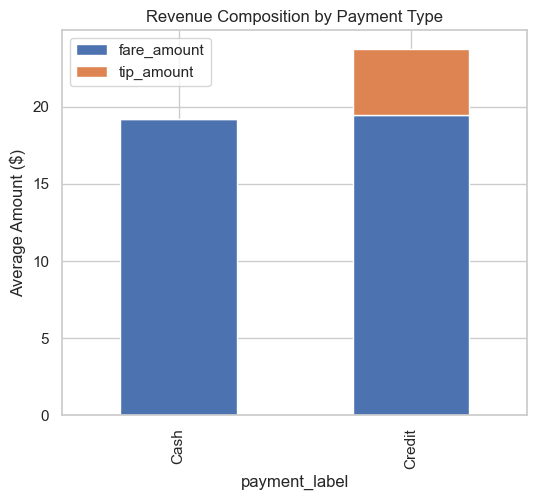

In [53]:
revenue_breakdown = df_pay.groupby("payment_label")[["fare_amount","tip_amount"]].mean()

revenue_breakdown.plot(kind="bar", stacked=True, figsize=(6,5))
plt.ylabel("Average Amount ($)")
plt.title("Revenue Composition by Payment Type")
plt.show()

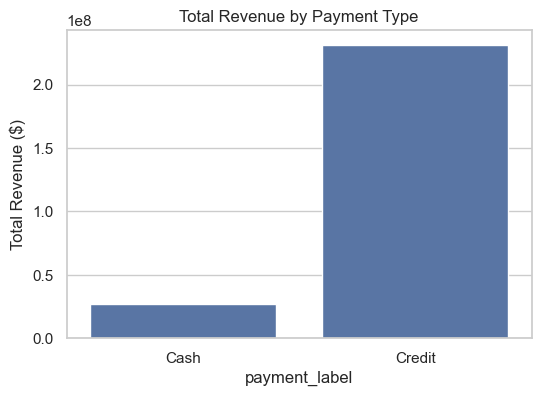

In [58]:
total_revenue = df_pay.groupby("payment_label")["total_amount"].sum()

plt.figure(figsize=(6,4))
sns.barplot(x=total_revenue.index, y=total_revenue.values)
plt.ylabel("Total Revenue ($)")
plt.title("Total Revenue by Payment Type")
plt.show()